In [1]:
import pandas as pd

biometric_files = [
    'api_data_aadhar_biometric/api_data_aadhar_biometric_0_500000.csv',
    'api_data_aadhar_biometric/api_data_aadhar_biometric_500000_1000000.csv',
    'api_data_aadhar_biometric/api_data_aadhar_biometric_1000000_1500000.csv',
    'api_data_aadhar_biometric/api_data_aadhar_biometric_1500000_1861108.csv'
]

demographic_files = [
    'api_data_aadhar_demographic/api_data_aadhar_demographic_0_500000.csv',
    'api_data_aadhar_demographic/api_data_aadhar_demographic_500000_1000000.csv',
    'api_data_aadhar_demographic/api_data_aadhar_demographic_1000000_1500000.csv',
    'api_data_aadhar_demographic/api_data_aadhar_demographic_1500000_2000000.csv',
    'api_data_aadhar_demographic/api_data_aadhar_demographic_2000000_2071700.csv'
]

enrolment_files = [
    'api_data_aadhar_enrolment/api_data_aadhar_enrolment_0_500000.csv',
    'api_data_aadhar_enrolment/api_data_aadhar_enrolment_500000_1000000.csv',
    'api_data_aadhar_enrolment/api_data_aadhar_enrolment_1000000_1006029.csv'
]

# Load and concatenate biometric data
df_biometric = pd.concat([pd.read_csv(f, on_bad_lines='skip', engine='python') for f in biometric_files])
print('df_biometric loaded and concatenated. Head:')
print(df_biometric.head())

# Load and concatenate demographic data
df_demographic = pd.concat([pd.read_csv(f, on_bad_lines='skip', engine='python') for f in demographic_files])
print('\ndf_demographic loaded and concatenated. Head:')
print(df_demographic.head())

# Load and concatenate enrolment data
df_enrolment = pd.concat([pd.read_csv(f, on_bad_lines='skip', engine='python') for f in enrolment_files])
print('\ndf_enrolment loaded and concatenated. Head:')
print(df_enrolment.head())
df_combined = pd.merge(df_biometric, df_demographic, on=['date', 'state', 'district', 'pincode'], how='outer', suffixes=('_biometric', '_demographic'))

# Then merge with enrolment data
df_combined = pd.merge(df_combined, df_enrolment, on=['date', 'state', 'district', 'pincode'], how='outer', suffixes=('_combined', '_enrolment'))

print('\nFinal combined DataFrame head:')
print(df_combined.head())
print('\nFinal combined DataFrame info:')
df_combined.info()

df_biometric loaded and concatenated. Head:
         date              state      district  pincode  bio_age_5_17  \
0  01-03-2025            Haryana  Mahendragarh   123029           280   
1  01-03-2025              Bihar     Madhepura   852121           144   
2  01-03-2025  Jammu and Kashmir         Punch   185101           643   
3  01-03-2025              Bihar       Bhojpur   802158           256   
4  01-03-2025         Tamil Nadu       Madurai   625514           271   

   bio_age_17_  
0          577  
1          369  
2         1091  
3          980  
4          815  

df_demographic loaded and concatenated. Head:
         date           state    district  pincode  demo_age_5_17  \
0  01-03-2025   Uttar Pradesh   Gorakhpur   273213             49   
1  01-03-2025  Andhra Pradesh    Chittoor   517132             22   
2  01-03-2025         Gujarat      Rajkot   360006             65   
3  01-03-2025  Andhra Pradesh  Srikakulam   532484             24   
4  01-03-2025       Raj


Top 10 States by 'demo_age_5_17' Demographic Updates:
             state  demo_age_5_17
54   Uttar Pradesh       817268.0
32  Madhya Pradesh       415435.0
7            Bihar       404518.0
3   Andhra Pradesh       334981.0
49      Tamil Nadu       332979.0
33     Maharashtra       281116.0
27       Karnataka       270438.0
47       Rajasthan       266355.0
51       Telangana       254391.0
61     West Bengal       251835.0

Top 10 States by 'demo_age_17_plus' Demographic Updates:
             state  demo_age_17_
54   Uttar Pradesh     8045986.0
33     Maharashtra     4960861.0
7            Bihar     4723568.0
61     West Bengal     3783062.0
47       Rajasthan     2632618.0
32  Madhya Pradesh     2564425.0
3   Andhra Pradesh     2047966.0
49      Tamil Nadu     1976409.0
10    Chhattisgarh     1918618.0
19         Gujarat     1687491.0


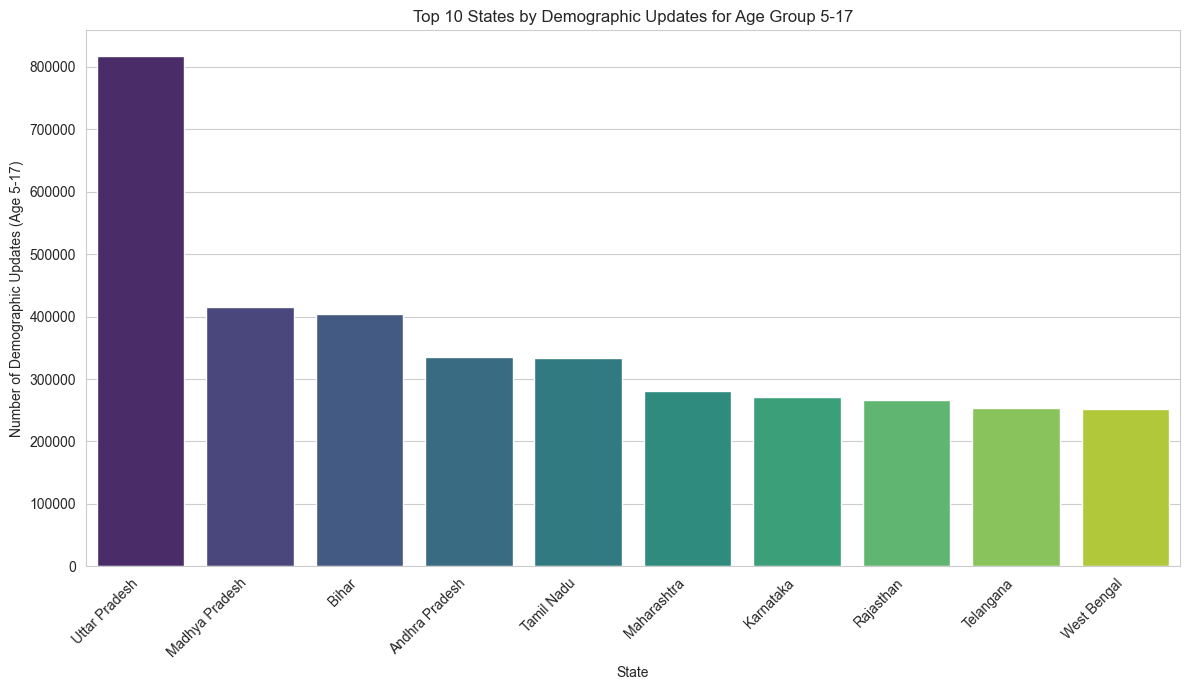

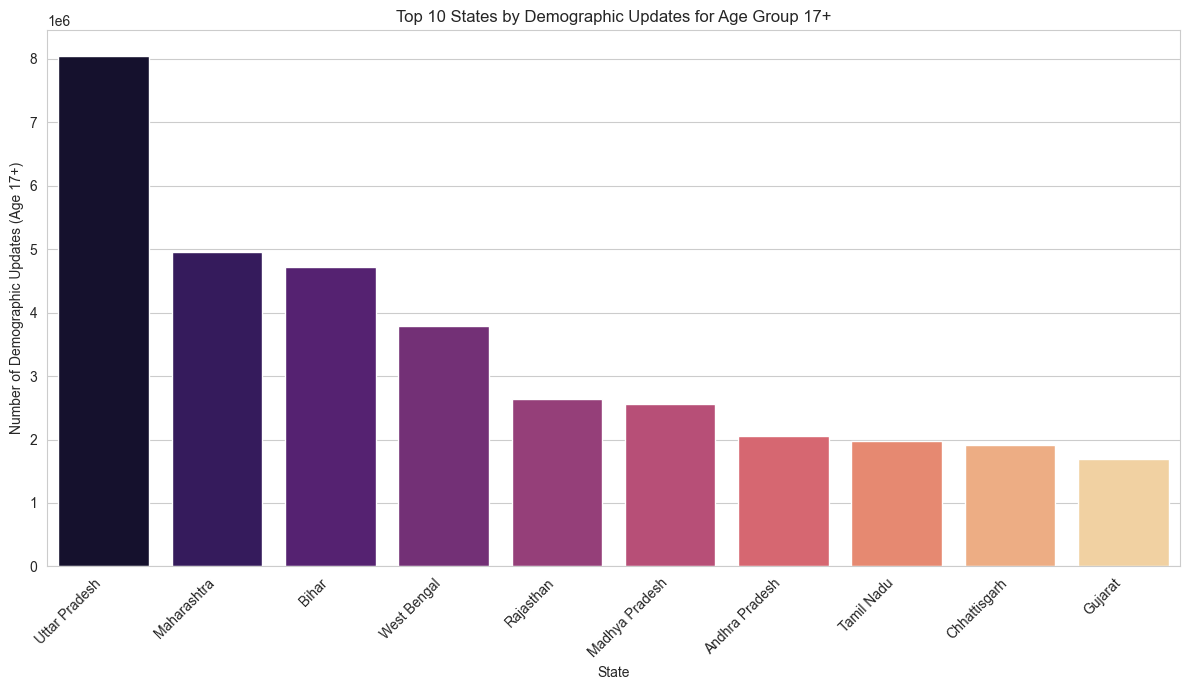

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# 1. Re-create df_demographic_by_state
# Use the merged dataframe created earlier (df_combined)
df_demographic_by_state = df_combined.groupby('state')[['demo_age_5_17', 'demo_age_17_']].sum().reset_index()

# 2. Calculate 'total_demographic_updates'
df_demographic_by_state['total_demographic_updates'] = df_demographic_by_state['demo_age_5_17'] + df_demographic_by_state['demo_age_17_']

# 3. Identify the top 10 states with the highest 'demo_age_5_17' demographic updates
top_10_demo_5_17 = df_demographic_by_state.sort_values(by='demo_age_5_17', ascending=False).head(10)
print("\nTop 10 States by 'demo_age_5_17' Demographic Updates:")
print(top_10_demo_5_17[['state', 'demo_age_5_17']])

# 4. Identify the top 10 states with the highest 'demo_age_17_' demographic updates
top_10_demo_17_plus = df_demographic_by_state.sort_values(by='demo_age_17_', ascending=False).head(10)
print("\nTop 10 States by 'demo_age_17_plus' Demographic Updates:")
print(top_10_demo_17_plus[['state', 'demo_age_17_']])

# 5. Create a bar plot for top 10 states by 'demo_age_5_17' updates
plt.figure(figsize=(12, 7))
sns.barplot(x='state', y='demo_age_5_17', hue='state', data=top_10_demo_5_17, palette='viridis', legend=False)
plt.title('Top 10 States by Demographic Updates for Age Group 5-17')
plt.xlabel('State')
plt.ylabel('Number of Demographic Updates (Age 5-17)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 6. Create a bar plot for top 10 states by 'demo_age_17_' updates
plt.figure(figsize=(12, 7))
sns.barplot(x='state', y='demo_age_17_', hue='state', data=top_10_demo_17_plus, palette='magma', legend=False)
plt.title('Top 10 States by Demographic Updates for Age Group 17+')
plt.xlabel('State')
plt.ylabel('Number of Demographic Updates (Age 17+)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Top 10 States by 'demo_age_5_17' Demographic Updates:
             state  demo_age_5_17
54   Uttar Pradesh       817268.0
32  Madhya Pradesh       415435.0
7            Bihar       404518.0
3   Andhra Pradesh       334981.0
49      Tamil Nadu       332979.0
33     Maharashtra       281116.0
27       Karnataka       270438.0
47       Rajasthan       266355.0
51       Telangana       254391.0
61     West Bengal       251835.0

Top 10 States by 'demo_age_17_plus' Demographic Updates:
             state  demo_age_17_
54   Uttar Pradesh     8045986.0
33     Maharashtra     4960861.0
7            Bihar     4723568.0
61     West Bengal     3783062.0
47       Rajasthan     2632618.0
32  Madhya Pradesh     2564425.0
3   Andhra Pradesh     2047966.0
49      Tamil Nadu     1976409.0
10    Chhattisgarh     1918618.0
19         Gujarat     1687491.0


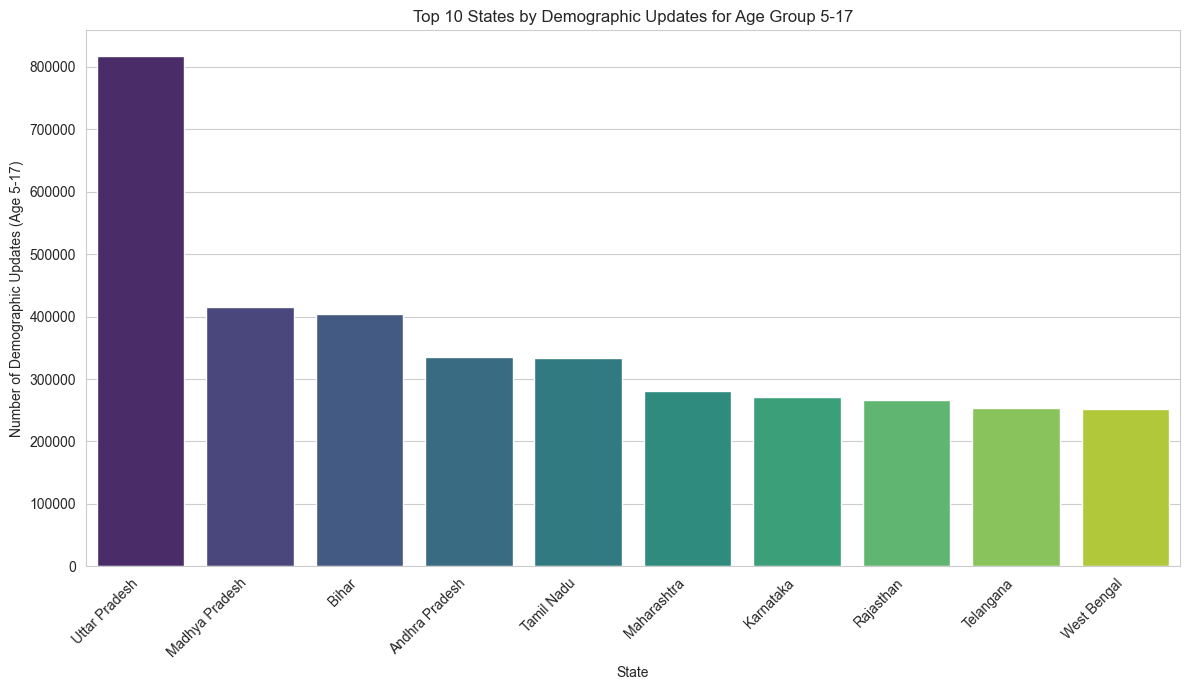

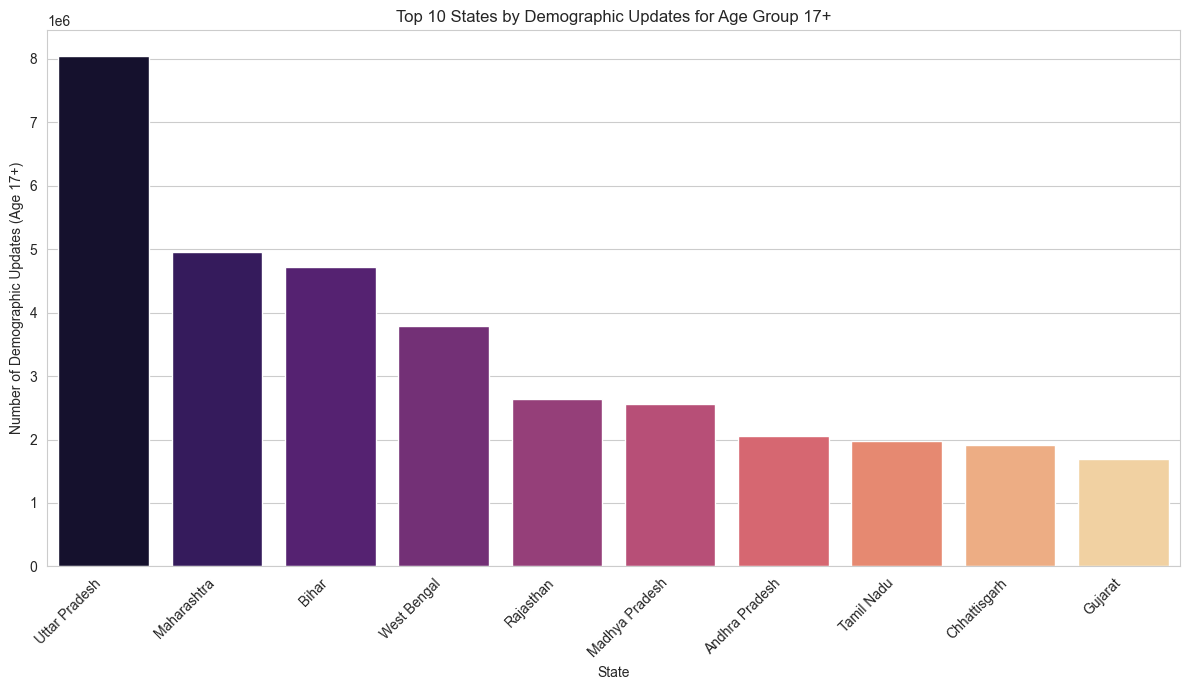

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# 1. Re-create df_demographic_by_state
df_demographic_by_state = df_combined.groupby('state')[['demo_age_5_17', 'demo_age_17_']].sum().reset_index()

# 2. Calculate 'total_demographic_updates'
df_demographic_by_state['total_demographic_updates'] = df_demographic_by_state['demo_age_5_17'] + df_demographic_by_state['demo_age_17_']

# 3. Identify the top 10 states with the highest 'demo_age_5_17' demographic updates
top_10_demo_5_17 = df_demographic_by_state.sort_values(by='demo_age_5_17', ascending=False).head(10)
print("\nTop 10 States by 'demo_age_5_17' Demographic Updates:")
print(top_10_demo_5_17[['state', 'demo_age_5_17']])

# 4. Identify the top 10 states with the highest 'demo_age_17_' demographic updates
top_10_demo_17_plus = df_demographic_by_state.sort_values(by='demo_age_17_', ascending=False).head(10)
print("\nTop 10 States by 'demo_age_17_plus' Demographic Updates:")
print(top_10_demo_17_plus[['state', 'demo_age_17_']])

# 5. Create a bar plot for top 10 states by 'demo_age_5_17' updates
plt.figure(figsize=(12, 7))
sns.barplot(x='state', y='demo_age_5_17', hue='state', data=top_10_demo_5_17, palette='viridis', legend=False)
plt.title('Top 10 States by Demographic Updates for Age Group 5-17')
plt.xlabel('State')
plt.ylabel('Number of Demographic Updates (Age 5-17)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 6. Create a bar plot for top 10 states by 'demo_age_17_' updates
plt.figure(figsize=(12, 7))
sns.barplot(x='state', y='demo_age_17_', hue='state', data=top_10_demo_17_plus, palette='magma', legend=False)
plt.title('Top 10 States by Demographic Updates for Age Group 17+')
plt.xlabel('State')
plt.ylabel('Number of Demographic Updates (Age 17+)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Monthly Enrolment Trends Head:
   month   age_0_5  age_5_17  age_18_greater
0      3    5367.0    7407.0          3808.0
1      4  163214.0   99249.0         26448.0
2      5  113207.0   80699.0         17660.0
3      6  110654.0  106643.0         17572.0
4      7  358482.0  285159.0         36989.0

Monthly Demographic Trends Head:
   month  demo_age_5_17  demo_age_17_
0      3       976095.0    10171463.0
1      4       198744.0     1316928.0
2      5       204893.0     1361394.0
3      6       197767.0     1487795.0
4      7       288449.0     1932266.0


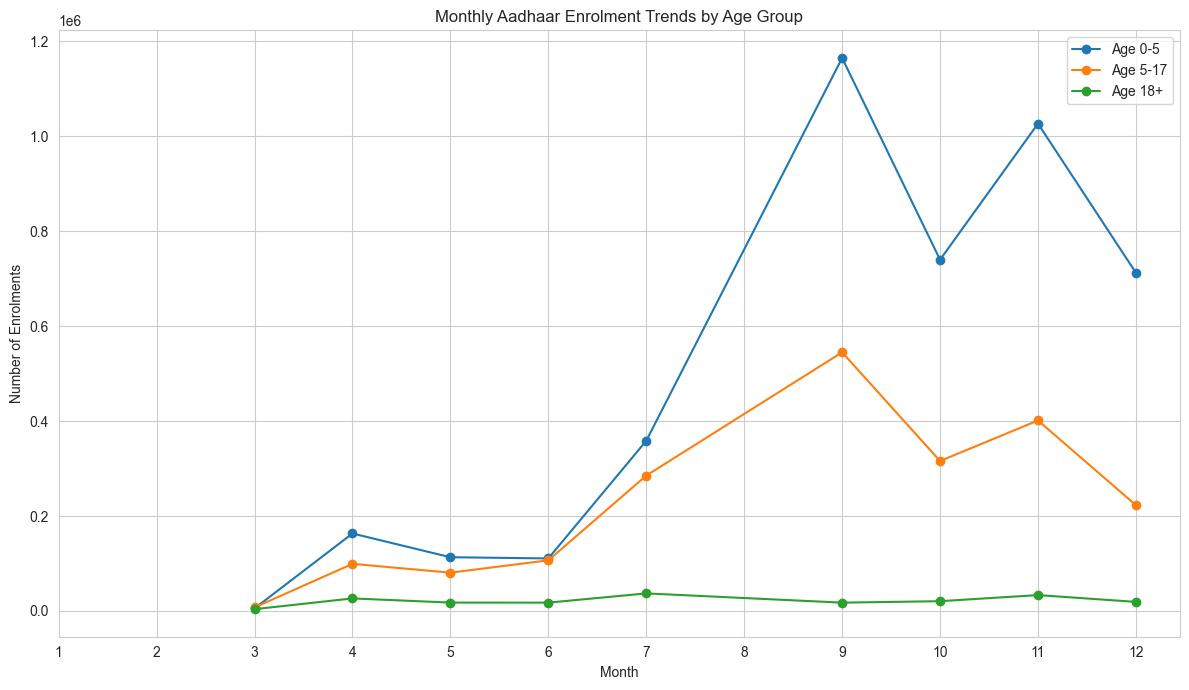

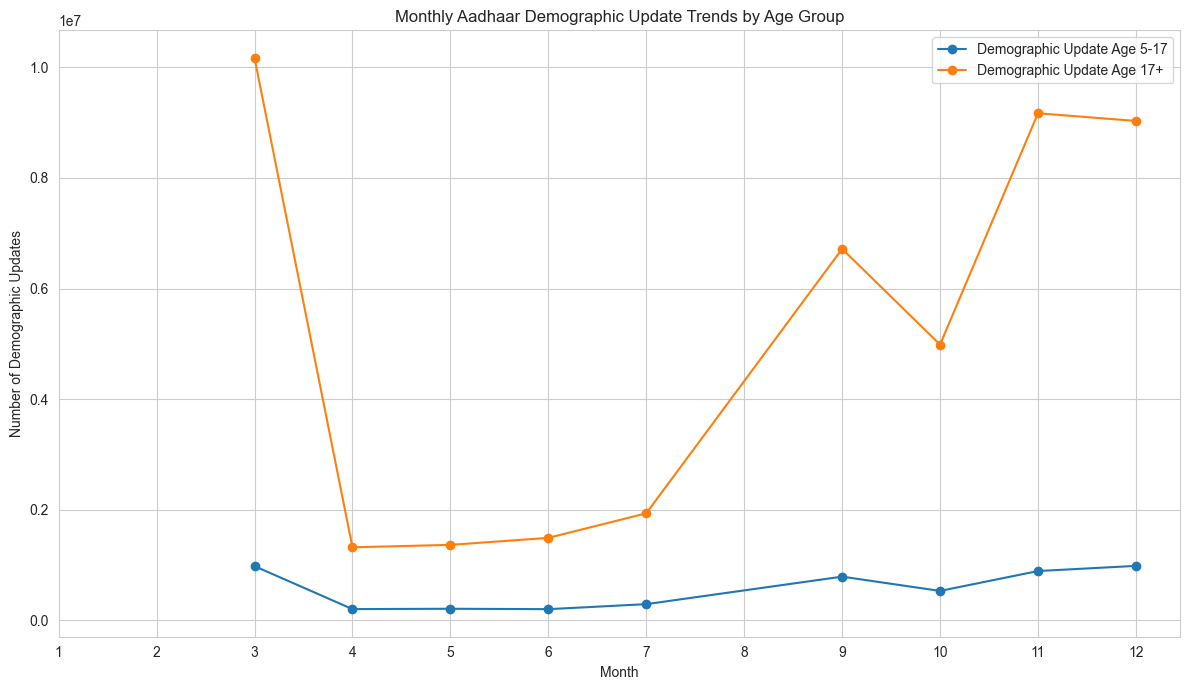

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Re-create df_daily_enrolment_trends and df_daily_demographic_trends from df_combined
df_daily_enrolment_trends = df_combined.groupby('date')[['age_0_5', 'age_5_17', 'age_18_greater']].sum().reset_index()
df_daily_demographic_trends = df_combined.groupby('date')[['demo_age_5_17', 'demo_age_17_']].sum().reset_index()

# Ensure 'date' is datetime for monthly grouping
df_daily_enrolment_trends['date'] = pd.to_datetime(df_daily_enrolment_trends['date'], format='%d-%m-%Y')
df_daily_demographic_trends['date'] = pd.to_datetime(df_daily_demographic_trends['date'], format='%d-%m-%Y')

# 1. Extract the month from the 'date' column
df_daily_enrolment_trends['month'] = df_daily_enrolment_trends['date'].dt.month
df_daily_demographic_trends['month'] = df_daily_demographic_trends['date'].dt.month

# 2. Group df_daily_enrolment_trends by month
df_monthly_enrolment_trends = df_daily_enrolment_trends.groupby('month')[['age_0_5', 'age_5_17', 'age_18_greater']].sum().reset_index()

# 3. Group df_daily_demographic_trends by month
df_monthly_demographic_trends = df_daily_demographic_trends.groupby('month')[['demo_age_5_17', 'demo_age_17_']].sum().reset_index()

print("\nMonthly Enrolment Trends Head:")
print(df_monthly_enrolment_trends.head())

print("\nMonthly Demographic Trends Head:")
print(df_monthly_demographic_trends.head())

# 4. Create a line plot for monthly enrolment trends
plt.figure(figsize=(12, 7))
plt.plot(df_monthly_enrolment_trends['month'], df_monthly_enrolment_trends['age_0_5'], label='Age 0-5', marker='o')
plt.plot(df_monthly_enrolment_trends['month'], df_monthly_enrolment_trends['age_5_17'], label='Age 5-17', marker='o')
plt.plot(df_monthly_enrolment_trends['month'], df_monthly_enrolment_trends['age_18_greater'], label='Age 18+', marker='o')
plt.title('Monthly Aadhaar Enrolment Trends by Age Group')
plt.xlabel('Month')
plt.ylabel('Number of Enrolments')
plt.xticks(range(1, 13))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 5. Create a line plot for monthly demographic update trends
plt.figure(figsize=(12, 7))
plt.plot(df_monthly_demographic_trends['month'], df_monthly_demographic_trends['demo_age_5_17'], label='Demographic Update Age 5-17', marker='o')
plt.plot(df_monthly_demographic_trends['month'], df_monthly_demographic_trends['demo_age_17_'], label='Demographic Update Age 17+', marker='o')
plt.title('Monthly Aadhaar Demographic Update Trends by Age Group')
plt.xlabel('Month')
plt.ylabel('Number of Demographic Updates')
plt.xticks(range(1, 13))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()